In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
import networkx as nx

# Boids

In [55]:
def get_adjacency(p):
    A = np.zeros((N, N))
    for j in range(N):
        for i in range(j): # don't loop more than needed
            r = np.linalg.norm(p[i] - p[j])
            if r <= R:
                A[i, j] = 1
    A += A.T # symmetric so this works
    return A

def get_u_sep(p, v, A):
    u_sep = np.zeros((N, 2))
    for i in range(N):
        tmp = np.zeros((N, 2))
        for j in range(N):
            if i == j or A[i, j] == 0:
                continue
            r = p[i] - p[j]
            rmag = np.linalg.norm(r)
            if rmag > 1e-8: # reject anything too small - avoid dividing by zero (this shouldnt be an issue in practice but better safe than sorry)
                tmp[j] = max(0, r0 - rmag)*r/rmag
        u_sep[i] = k_sep*np.sum(tmp, axis=0)
    return u_sep

def get_u_ali(p, v, A, d):
    u_ali = np.zeros((N, 2))
    for i in range(N):
        if d[i] > 0:
            vbar = np.sum(A[i, :, None] * v, axis=0) / d[i]
            u_ali[i] = k_ali * (vbar - v[i])
    return u_ali

def get_u_coh(p, v, A, d):
    u_coh = np.zeros((N, 2))
    for i in range(N):
        if d[i] > 0:
            pbar = np.sum(A[i, :, None]*p, axis=0) / d[i]
            u_coh[i] = k_coh * (pbar - p[i])
    return u_coh

def f(t, x):
    p = x[:2*N].reshape(N, 2)
    v = x[2*N:].reshape(N, 2)

    A = get_adjacency(p)
    d = A @ np.ones(N)

    u_sep = get_u_sep(p,v,A)
    u_ali = get_u_ali(p,v,A,d)
    u_coh = get_u_coh(p,v,A,d)

    pdot = v
    vdot = u_sep + u_ali + u_coh # get full control

    return np.concatenate((pdot,vdot)).flatten()




def plot_boid_trajectories(sol, N,title = "Boid Trajectories"):

    p_traj = sol.y[:2*N,:] 
    T = len(sol.t)
    p_traj = p_traj.reshape(N,2,T)

    # do plotting
    plt.figure(figsize=(6,6))
    for i in range(N):
        plt.plot(p_traj[i, 0, :], p_traj[i, 1, :],lw=1.2,alpha=0.8)
        plt.scatter(p_traj[i, 0, -1], p_traj[i, 1, -1],s=10)  # final position dots 
    
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis("equal")
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.show()

def get_D_L(A): # from hw 1
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) 
    L = D-A
    return D,L

def get_lambda_2(sol):
    lambda_2_ary = np.zeros(len(t_eval))
    components_ary = np.zeros(len(t_eval))
    for i, t in enumerate(t_eval):
        p = sol.y[:2*N, i].reshape(N, 2)
        A = get_adjacency(p)
        D,L = get_D_L(A)
        vals = np.real(np.linalg.eigvals(L))
        vals_sorted = np.sort(vals)
        G = nx.Graph(A)
        nc=nx.number_connected_components(G) # could compute multiplicity like in hint but I am lazy and know about this
        components_ary[i] = nc # use multiplicity of zero eval to find lambda_2
        lambda_2 = vals_sorted[nc]
        #print(lambda_2)
        lambda_2_ary[i]=lambda_2
    return lambda_2_ary, components_ary


In [91]:
N = 20
x20 = 0.7 * np.random.uniform(-1,1,(2*N,2)) # 2*N to also get initial velocities

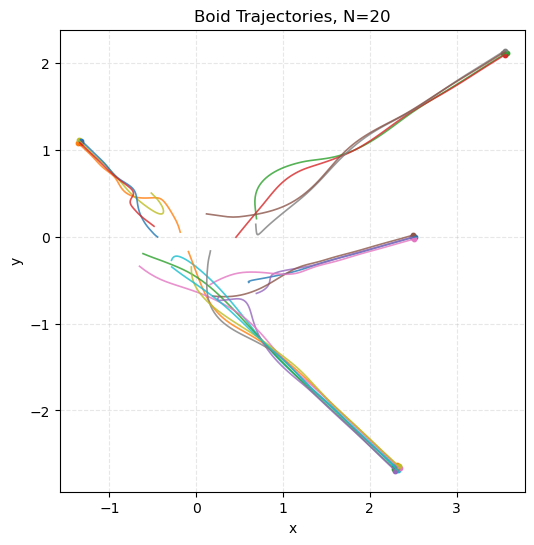

In [92]:
N=20
R = 0.3
k_sep = 2
k_ali = 1
k_coh = 2
r0 = 0.05

# integrate
tspan = (0, 8)
t_eval = np.arange(tspan[0], tspan[1], 0.1)
b20_sol = solve_ivp(f, tspan, x20.flatten(), t_eval=t_eval)

plot_boid_trajectories(b20_sol,N,"Boid Trajectories, N=20")

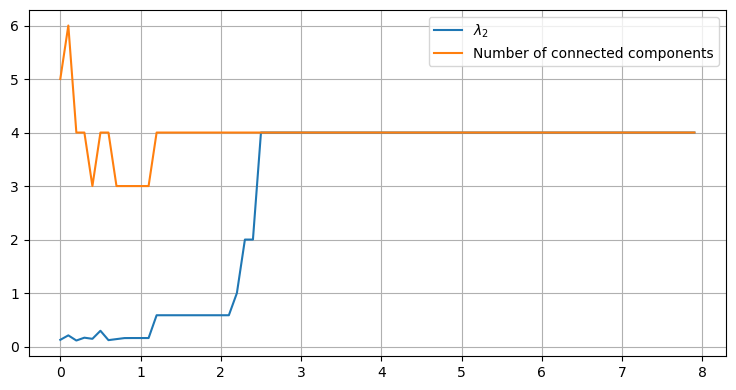

In [93]:
l2,ca = get_lambda_2(b20_sol)

plt.figure(figsize=(9,4.5))
plt.plot(t_eval,l2,label =r'$\lambda_2$')
plt.plot(t_eval,ca,label = "Number of connected components")

plt.legend()
plt.grid()
plt.show()

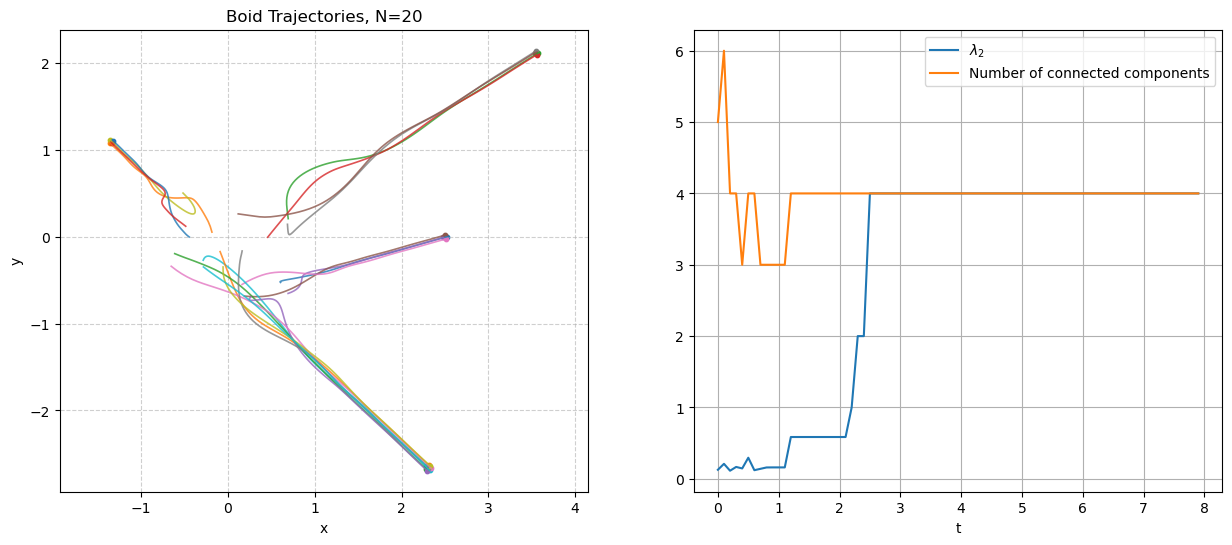

In [94]:
def plot_boid_trajectories2(sol,l2,ca, N,title = "Boid Trajectories"):

    p_traj = sol.y[:2*N,:] 
    T = len(sol.t)
    p_traj = p_traj.reshape(N,2,T)


    fig, ax = plt.subplots(1,2, figsize = (15,6))

    for i in range(N):
        ax[0].plot(p_traj[i, 0, :], p_traj[i, 1, :],lw=1.2,alpha=0.8)
        ax[0].scatter(p_traj[i, 0, -1], p_traj[i, 1, -1],s=10)  # final position dots 
    
    ax[0].set_title(title)
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    ax[0].axis("equal")
    ax[0].grid(True, linestyle='--', alpha=0.6)


    ax[1].plot(t_eval,l2,label =r'$\lambda_2$')
    ax[1].plot(t_eval,ca,label = "Number of connected components")
    ax[1].set_xlabel("t")

    ax[1].legend()
    ax[1].grid()
    plt.show()

plot_boid_trajectories2(b20_sol, l2,ca, N , "Boid Trajectories, N=20")

In [103]:
N = 50
x50 = 0.7 * np.random.uniform(-1,1,(2*N,2))

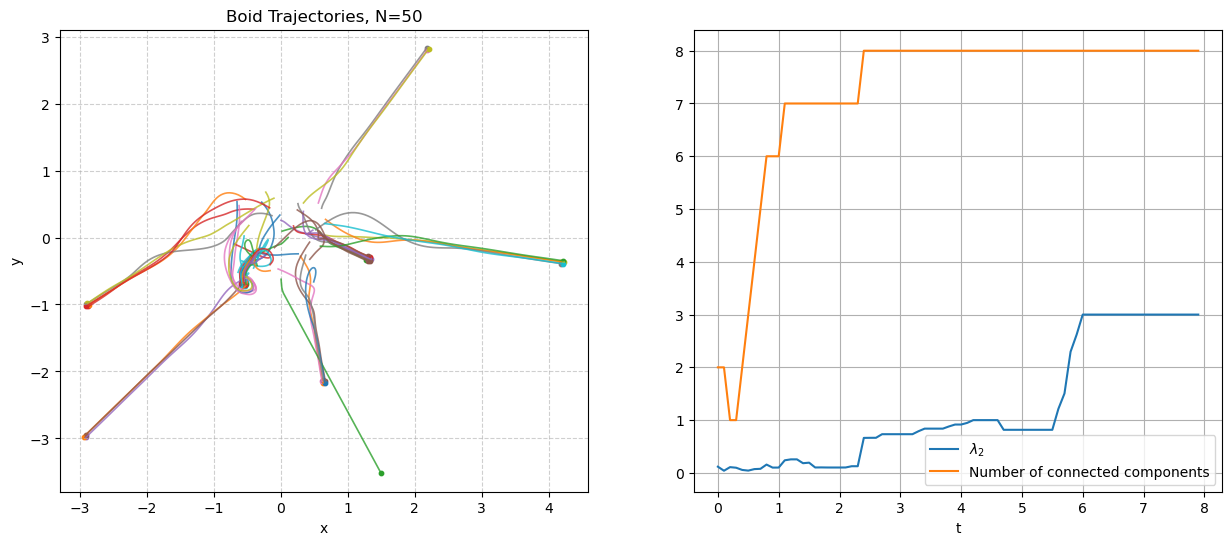

In [113]:
N=50
R = 0.3
k_sep = 2
k_ali = 1
k_coh = 2
r0 = 0.05

# integrate
b50_sol = solve_ivp(f, tspan, x50.flatten(), t_eval=t_eval)

#plot_boid_trajectories(b50_sol,N,"Boid Trajectories, N=50")
l2,ca = get_lambda_2(b50_sol)
plot_boid_trajectories2(b50_sol, l2,ca, N , "Boid Trajectories, N=50")

# Olfati–Saber

In [105]:
def signorm(z,epsilon = 0.1):
    return (np.sqrt(1+epsilon*np.linalg.norm(z)**2)-1)/epsilon

h = 0.5
def bump(s,h=0.5):
    if 0 <= s and s <= h:
        return 1
    elif h<= s and s<= 1:
        return 1/2*(1 + np.cos(np.pi * (s-h)/(1-h)))
    else:
        return 0
    
def get_adjacency_2(p):
    A = np.zeros((N, N))
    for j in range(N):
        for i in range(j):
            A[i,j] = bump(np.linalg.norm(p[i]-p[j])/R)
    A += A.T
    return A

def sigma1(z):
    return z/(np.sqrt(1+z*z))

def phi(z,a=0.1,b=0.5):
    c = abs(a-b)/np.sqrt(4*a*b)
    return 0.5*((a+b)*sigma1(z+c)+(a-b))

def phi_alpha(z):
    z1 = bump(z/R)
    z2 = phi(z-d)
    return z1*z2

def gradz(pi,pj):
    return (pi-pj)/(np.sqrt(1 + epsilon*np.linalg.norm(pi-pj)**2))

def get_u_int(p,v,A):
    u_int = np.zeros((N, 2))
    for i in range(N):
        u_int[i] = np.sum(np.array([A[i,j]*phi_alpha(signorm(p[i]-p[j]))*gradz(p[i],p[j]) for j in range(N)]))
    return u_int



def get_u_ali_2(p, v, A):
    u_ali = np.zeros((N, 2))
    for i in range(N):
        u_ali[i] = -np.sum(np.array([A[i,j]*(v[i]-v[j]) for j in range(N)]),axis=0)
    return u_ali
c1=1.
c2=1.
def get_u_gamma_static(p, v, A,c1,c2):
    u_gamma = np.zeros((N,2))
    for i in range(N):
        u_gamma[i]=-c1*p[i]-c2*v[i]
    return u_gamma

def get_u_gamma_dynamic(p, v, A,c1,c2,vgamma,t):
    u_gamma = np.zeros((N,2))
    for i in range(N):
        u_gamma[i]=-c1*(p[i]-vgamma*t)-c2*(v[i]-vgamma)
    return u_gamma


def f_static(t, x):
    p = x[:2*N].reshape(N, 2)
    v = x[2*N:].reshape(N, 2)

    A = get_adjacency_2(p)

    u_int = get_u_int(p, v, A)
    u_ali = get_u_ali_2(p, v, A)
    u_gamma = get_u_gamma_static(p,v,A,c1,c2)

    pdot = v
    vdot = u_int + u_ali + u_gamma

    return np.concatenate((pdot, vdot)).flatten()

def f_dynamic(t, x):
    p = x[:2*N].reshape(N, 2)
    v = x[2*N:].reshape(N, 2)

    A = get_adjacency_2(p)

    u_int = get_u_int(p, v, A)
    u_ali = get_u_ali_2(p, v, A)
    u_gamma = get_u_gamma_dynamic(p, v, A,c1,c2,vgamma,t)

    pdot = v
    vdot = u_int + u_ali + u_gamma

    return np.concatenate((pdot, vdot)).flatten()

def get_avg_velocity_error(sol):
    v_traj = sol.y[2*N:,:]  
    v_traj = v_traj.reshape(N, 2, len(t_eval)) 

    err = np.zeros(len(t_eval))
    for k in range(len(t_eval)):
        v_diff = v_traj[:, :, k] - vgamma # difference
        err[k] = np.mean(np.linalg.norm(v_diff, axis=1)) #average of norm of difference

    return err

In [106]:
def plot_boid_trajectories3(sol,l2,ca,v1, N,title = "Boid Trajectories"):

    p_traj = sol.y[:2*N,:] 
    T = len(sol.t)
    p_traj = p_traj.reshape(N,2,T)


    fig, ax = plt.subplots(1,3, figsize = (18,6))

    for i in range(N):
        ax[0].plot(p_traj[i, 0, :], p_traj[i, 1, :],lw=1.2,alpha=0.8)
        ax[0].scatter(p_traj[i, 0, -1], p_traj[i, 1, -1],s=10)  # final position dots 
    
    ax[0].set_title(title)
    ax[0].set_xlabel("x")
    ax[0].set_ylabel("y")
    ax[0].axis("equal")
    ax[0].grid(True, linestyle='--', alpha=0.6)


    ax[1].plot(t_eval,l2,label =r'$\lambda_2$')
    ax[1].plot(t_eval,ca,label = "Number of connected components")
    ax[1].set_xlabel("t")

    ax[1].legend(loc = "upper left")
    ax[1].grid()

    ax[2].plot(t_eval,v1)
    ax[2].set_title("average velocity error")
    ax[2].set_xlabel("t")
    ax[2].grid()

    plt.show()

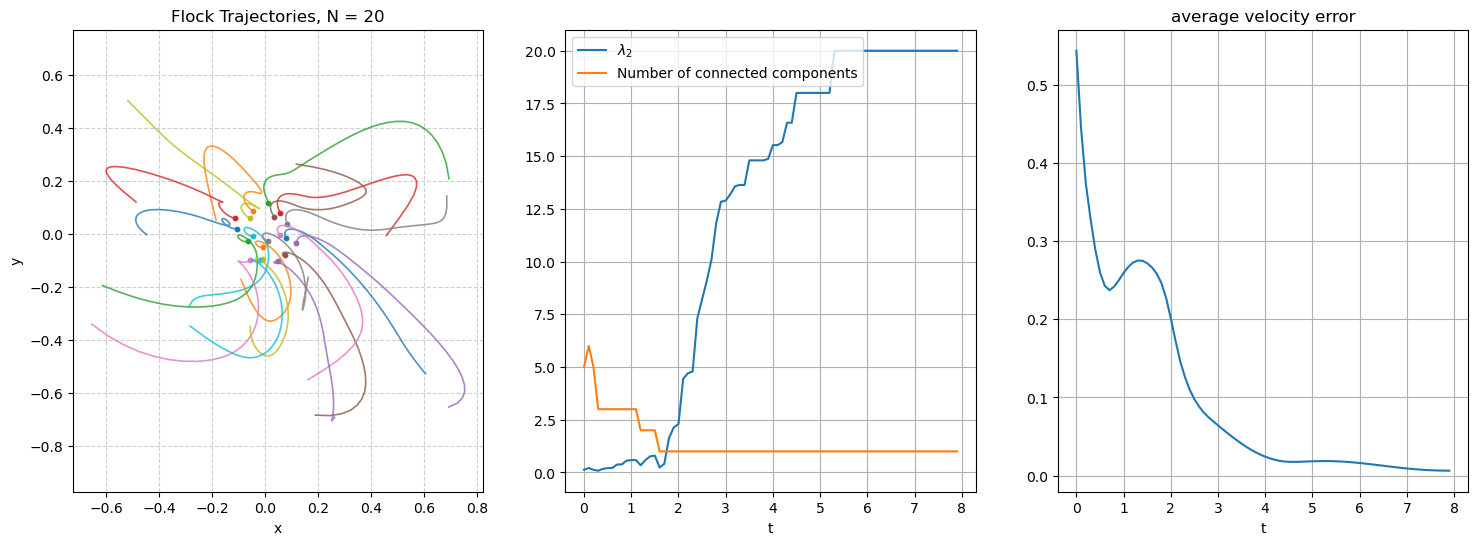

In [107]:
N = 20
epsilon = 0.1
R = 0.3
d = 0.1
h = 0.3

# integrate
tspan = (0, 8)
t_eval = np.arange(tspan[0], tspan[1], 0.1)
o20_sol_s = solve_ivp(f_static, tspan, x20.flatten(), t_eval=t_eval)
l2,ca = get_lambda_2(o20_sol_s)
vgamma = np.zeros(2)
v1 = get_avg_velocity_error(o20_sol_s)

#plot_boid_trajectories(o20_sol_s,N, "Flock Trajectories, N = 20")
plot_boid_trajectories3(o20_sol_s,l2,ca,v1, N,title = "Flock Trajectories, N = 20")

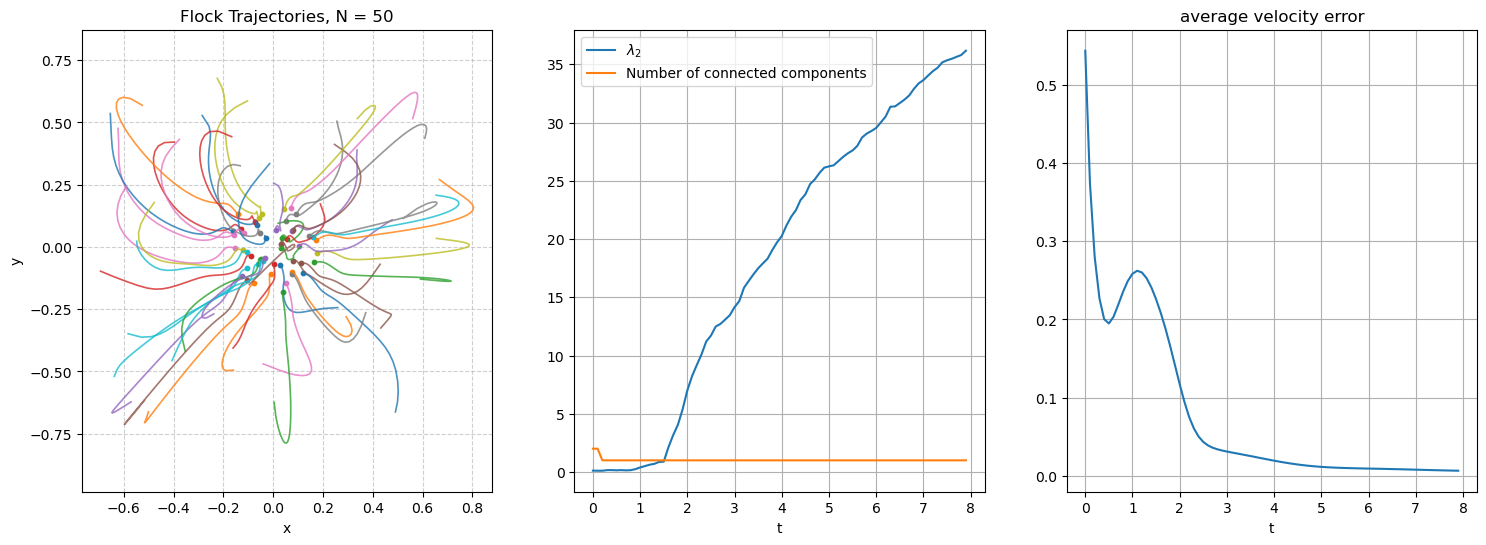

In [108]:
N = 50
o50_sol_s = solve_ivp(f_static, tspan, x50.flatten(), t_eval=t_eval)

l2,ca = get_lambda_2(o50_sol_s)
vgamma = np.zeros(2)
v1 = get_avg_velocity_error(o50_sol_s)

#plot_boid_trajectories(o50_sol_s,N, "Flock Trajectories, N=50")

plot_boid_trajectories3(o50_sol_s,l2,ca,v1, N,title = "Flock Trajectories, N = 50")

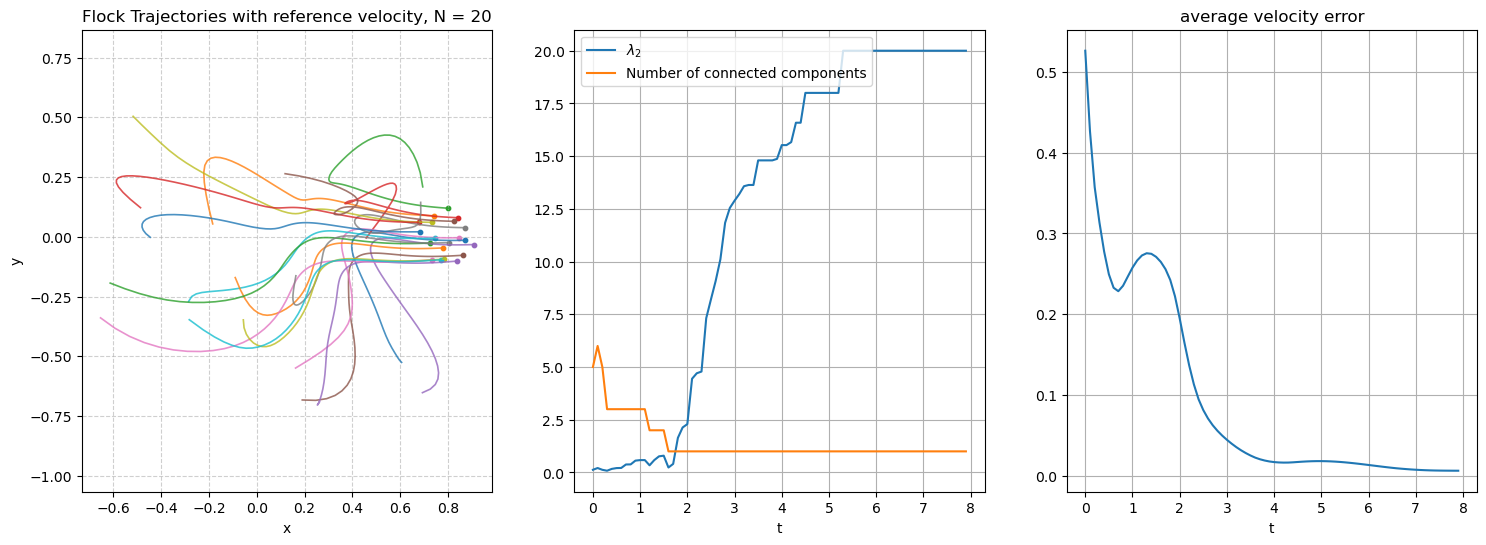

In [109]:
N = 20
vgamma = np.array([[0.1,0]])
# integrate
#tspan = (0, 15)
#t_eval = np.arange(tspan[0], tspan[1], 0.1)
o20_sol_d = solve_ivp(f_dynamic, tspan, x20.flatten(), t_eval=t_eval)


l2,ca = get_lambda_2(o20_sol_d)
v1 = get_avg_velocity_error(o20_sol_d)

plot_boid_trajectories3(o20_sol_d,l2,ca,v1, N,title = "Flock Trajectories with reference velocity, N = 20")

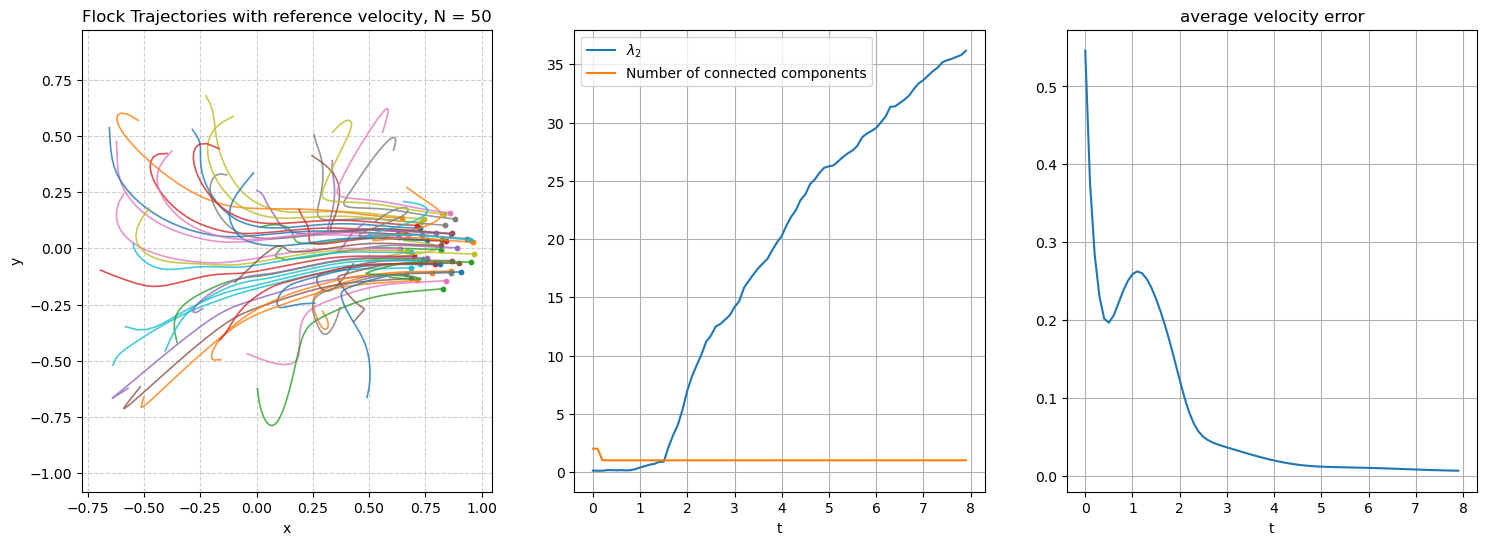

In [110]:
N = 50
vgamma = np.array([[0.1,0]])
# integrate
#tspan = (0, 15)
#t_eval = np.arange(tspan[0], tspan[1], 0.1)
o50_sol_d = solve_ivp(f_dynamic, tspan, x50.flatten(), t_eval=t_eval)


l2,ca = get_lambda_2(o50_sol_d)
v1 = get_avg_velocity_error(o50_sol_d)


plot_boid_trajectories3(o50_sol_d,l2,ca,v1, N,title = "Flock Trajectories with reference velocity, N = 50")

NameError: name 'v2' is not defined

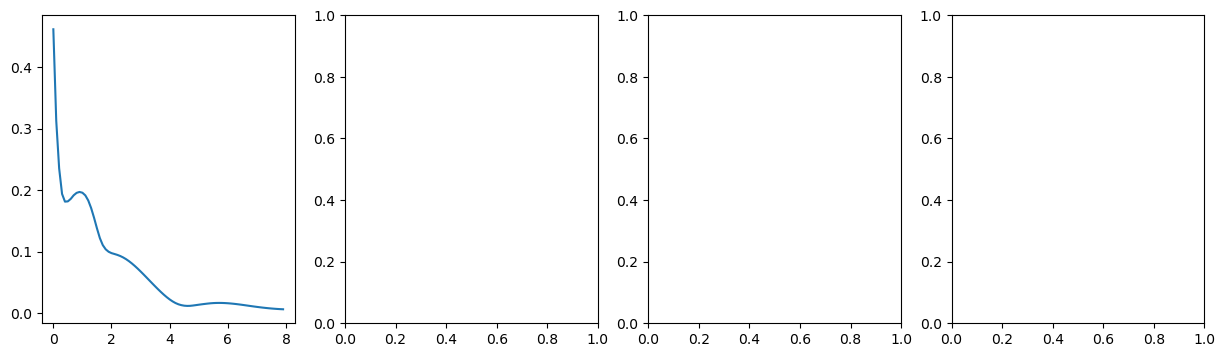

In [88]:
fig, ax = plt.subplots(1,4,figsize = (15,4))
ax[0].plot(t_eval, v1)
ax[1].plot(t_eval, v2)
ax[2].plot(t_eval, v3)
ax[3].plot(t_eval, v4)

for i in range(4):
    ax[i].grid()
    ax[i].set_xlabel("t")
    ax[i].set_ylabel("avg velocity error")

plt.tight_layout()

# animation

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

def animate_boids(sol, N, interval=100, trail_length=20, save_path=None):
    """
    Animate the trajectories of N boids from solve_ivp solution `sol`.
    Falls back to PillowWriter if ffmpeg is unavailable.
    """

    # --- Handle sol.y shape safely ---
    y = sol.y
    if y.ndim == 1:
        y = y.reshape(y.shape[0], 1)

    state_dim, T = y.shape
    if state_dim < 2*N:
        raise ValueError(f"Expected state dimension >= {2*N}, got {state_dim}")

    # Extract positions: (N, 2, T)
    p_block = y[:2*N, :]
    p_traj = p_block.reshape(N, 2, T)

    # Compute bounds
    xmin, xmax = np.min(p_traj[:, 0, :]), np.max(p_traj[:, 0, :])
    ymin, ymax = np.min(p_traj[:, 1, :]), np.max(p_traj[:, 1, :])
    if xmax - xmin < 1e-6: xmin, xmax = xmin - 0.5, xmax + 0.5
    if ymax - ymin < 1e-6: ymin, ymax = ymin - 0.5, ymax + 0.5
    pad_x = 0.05 * max(1.0, (xmax - xmin))
    pad_y = 0.05 * max(1.0, (ymax - ymin))

    # --- Figure setup ---
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(ymin - pad_y, ymax + pad_y)
    ax.set_title("Boid Simulation")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect('equal', adjustable='box')

    # Initialize objects
    init_pos = p_traj[:, :, 0]
    scat = ax.scatter(init_pos[:, 0], init_pos[:, 1], s=40, c='tab:blue')
    trails = [ax.plot([], [], lw=1, alpha=0.6)[0] for _ in range(N)]

    def init():
        scat.set_offsets(init_pos)
        for trail in trails:
            trail.set_data([], [])
        return [scat] + trails

    def update(frame):
        frame = int(frame % T)
        positions = p_traj[:, :, frame]
        scat.set_offsets(positions)
        for i, trail in enumerate(trails):
            start = max(0, frame - trail_length)
            trail.set_data(p_traj[i, 0, start:frame+1],
                           p_traj[i, 1, start:frame+1])
        return [scat] + trails

    ani = FuncAnimation(
        fig, update, frames=range(T),
        init_func=init, interval=interval, blit=True, repeat=True
    )

    # --- Saving / Display ---
    if save_path:
        # Force PillowWriter for all cases (no ffmpeg required)
        writer = PillowWriter(fps=int(1000/interval))
        # Ensure filename ends with .gif
        if not save_path.lower().endswith(".gif"):
            save_path = save_path.rsplit(".", 1)[0] + ".gif"

        ani.save(save_path, writer=writer)
        plt.close(fig)
        print(f"Animation saved as GIF: {save_path}")
        return None
    else:
        # For notebooks / IPython
        from IPython.display import HTML
        return HTML(ani.to_jshtml())


In [21]:
animate_boids(o50_sol_s, 50, save_path="flocking.mp4")

Animation saved as GIF: flocking.gif
